# Загрузка данных

In [2]:
# Библиотеки для работы с данными
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import statsmodels.formula.api as smf

from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LinearRegression, Ridge
from sklearn.model_selection import GroupKFold, GridSearchCV, cross_val_score
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score, make_scorer
import shap

In [4]:
df_m1 = pd.read_csv ('df_m1_ols.csv', low_memory=False)

In [6]:
df_m1.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 41198 entries, 0 to 41197
Data columns (total 6 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   role_name        41198 non-null  object 
 1   experience_ord   41198 non-null  int64  
 2   schedule_id      41198 non-null  object 
 3   employment_id    41198 non-null  object 
 4   region_name      41198 non-null  object 
 5   salary_from_log  41198 non-null  float64
dtypes: float64(1), int64(1), object(4)
memory usage: 1.9+ MB


# Подготовка данных

In [8]:
features = ['role_name', 'experience_ord', 'schedule_id', 'employment_id']
group_col = 'region_name'
target = 'salary_from_log'

# Для OLS без CV — удаляем дубликаты только по структурным признакам + таргет
df_m1_ols = df_m1[features + [target]].drop_duplicates().reset_index(drop=True)
print(f"OLS без CV — после удаления дубликатов: {df_m1_ols.shape[0]} строк")

# Для GroupKFold и Ridge — учитываем region_name
df_m1_cv = df_m1[features + [target, group_col]].drop_duplicates().reset_index(drop=True)
print(f"CV модели — после удаления дубликатов: {df_m1_cv.shape[0]} строк")

OLS без CV — после удаления дубликатов: 11896 строк
CV модели — после удаления дубликатов: 41198 строк


# OLS без CV (robust SE) + визуализация влияния категорий

                            OLS Regression Results                            
Dep. Variable:        salary_from_log   R-squared:                       0.289
Model:                            OLS   Adj. R-squared:                  0.288
Method:                 Least Squares   F-statistic:                     288.6
Date:                Mon, 09 Mar 2026   Prob (F-statistic):               0.00
Time:                        16:48:46   Log-Likelihood:                -6204.2
No. Observations:               11896   AIC:                         1.244e+04
Df Residuals:                   11881   BIC:                         1.255e+04
Df Model:                          14                                         
Covariance Type:                  HC3                                         
                                                                           coef    std err          z      P>|z|      [0.025      0.975]
-------------------------------------------------------------------------

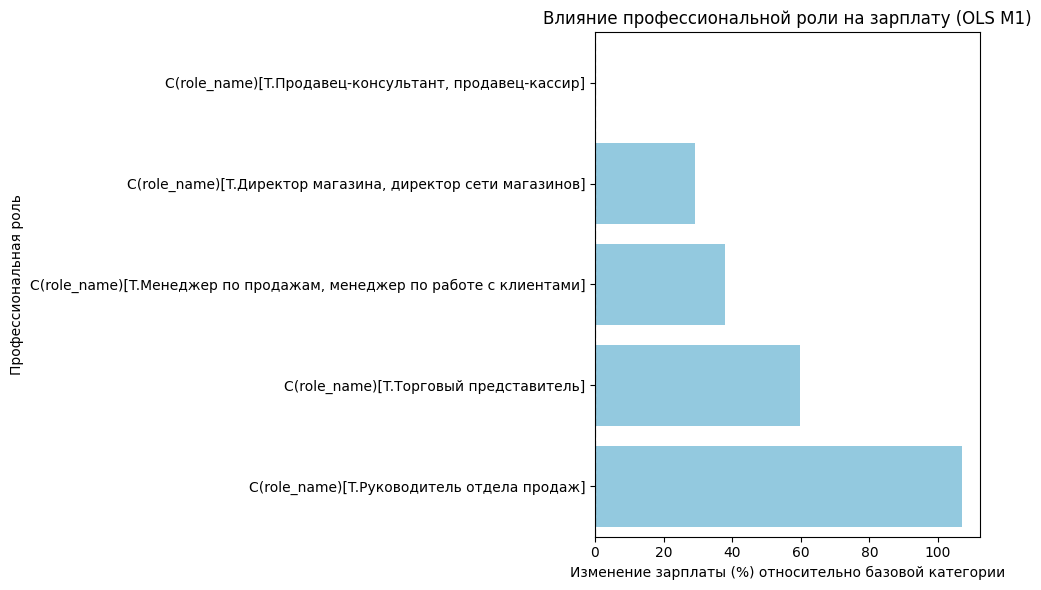

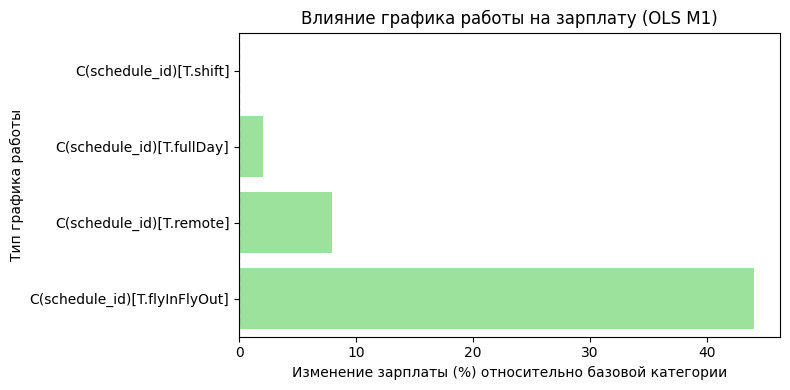

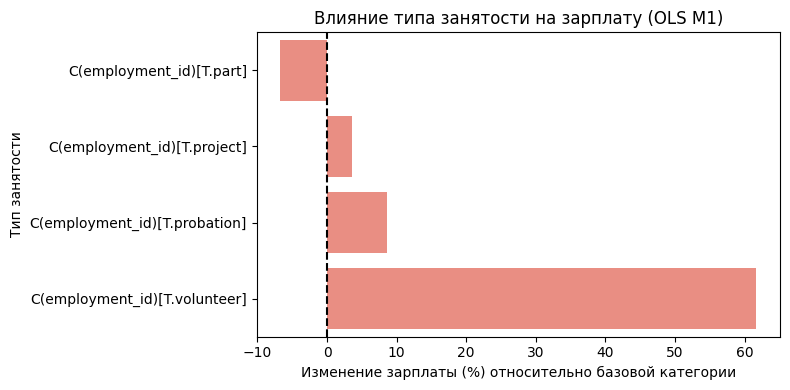

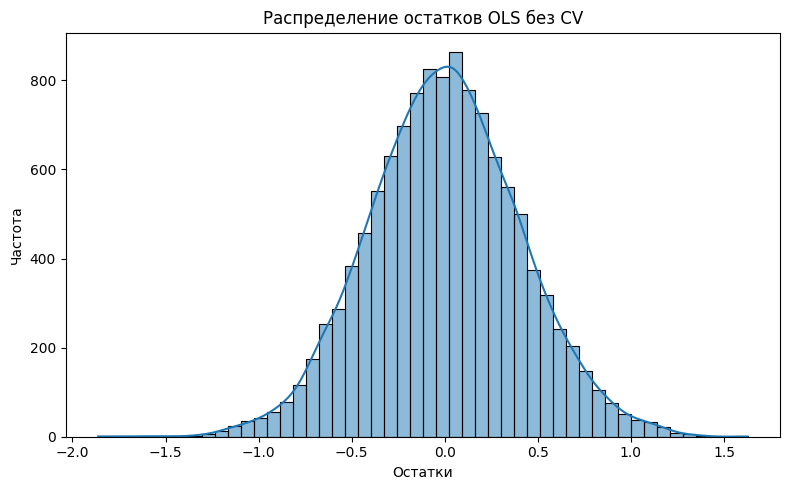

OLS без CV: RMSE=0.4076, MAE=0.3228, R2=0.2891


In [10]:
# Формула для OLS (robust SE)
formula = "salary_from_log ~ C(role_name) + experience_ord + C(schedule_id) + C(employment_id)"
ols_model = smf.ols(formula=formula, data=df_m1_ols).fit(cov_type='HC3')
print(ols_model.summary())

# Коэффициенты и процентное влияние
params = ols_model.params
conf = ols_model.conf_int()

results_df = pd.DataFrame({
    'feature': params.index,
    'coef': params.values,
    'ci_lower': conf[0],
    'ci_upper': conf[1]
}).reset_index(drop=True)

# Убираем интерсепт
results_df = results_df[results_df['feature'] != 'Intercept']

# Переводим коэффициенты в проценты изменения зарплаты
results_df['pct_effect'] = (np.expm1(results_df['coef'])) * 100
results_df['pct_lower'] = (np.expm1(results_df['ci_lower'])) * 100
results_df['pct_upper'] = (np.expm1(results_df['ci_upper'])) * 100

# Разделяем признаки по группам
role_effects = results_df[results_df['feature'].str.contains('role_name')].sort_values('pct_effect')
schedule_effects = results_df[results_df['feature'].str.contains('schedule_id')].sort_values('pct_effect')
employment_effects = results_df[results_df['feature'].str.contains('employment_id')].sort_values('pct_effect')

# ---- Визуализация влияния профессиональной роли ----
plt.figure(figsize=(10,6))
sns.barplot(data=role_effects, x='pct_effect', y='feature', color='skyblue')
plt.axvline(0, color='black', linestyle='--')
plt.xlabel("Изменение зарплаты (%) относительно базовой категории")
plt.ylabel("Профессиональная роль")
plt.title("Влияние профессиональной роли на зарплату (OLS M1)")
plt.tight_layout()
plt.show()

# ---- Визуализация влияния графика работы ----
plt.figure(figsize=(8,4))
sns.barplot(data=schedule_effects, x='pct_effect', y='feature', color='lightgreen')
plt.axvline(0, color='black', linestyle='--')
plt.xlabel("Изменение зарплаты (%) относительно базовой категории")
plt.ylabel("Тип графика работы")
plt.title("Влияние графика работы на зарплату (OLS M1)")
plt.tight_layout()
plt.show()

# ---- Визуализация влияния типа занятости ----
plt.figure(figsize=(8,4))
sns.barplot(data=employment_effects, x='pct_effect', y='feature', color='salmon')
plt.axvline(0, color='black', linestyle='--')
plt.xlabel("Изменение зарплаты (%) относительно базовой категории")
plt.ylabel("Тип занятости")
plt.title("Влияние типа занятости на зарплату (OLS M1)")
plt.tight_layout()
plt.show()

# ---- Распределение остатков ----
residuals = ols_model.resid
plt.figure(figsize=(8,5))
sns.histplot(residuals, bins=50, kde=True)
plt.title("Распределение остатков OLS без CV")
plt.xlabel("Остатки")
plt.ylabel("Частота")
plt.tight_layout()
plt.show()

# ---- Метрики на обучении ----
rmse_ols_simple = np.sqrt(mean_squared_error(df_m1_ols[target], ols_model.fittedvalues))
mae_ols_simple = mean_absolute_error(df_m1_ols[target], ols_model.fittedvalues)
r2_ols_simple = r2_score(df_m1_ols[target], ols_model.fittedvalues)

print(f"OLS без CV: RMSE={rmse_ols_simple:.4f}, MAE={mae_ols_simple:.4f}, R2={r2_ols_simple:.4f}")

# OLS с GroupKFold

In [24]:
categorical_features = ['role_name', 'schedule_id', 'employment_id']
numeric_features = ['experience_ord']

preprocessor = ColumnTransformer(transformers=[
    ('cat', OneHotEncoder(handle_unknown='ignore'), categorical_features),
    ('num', StandardScaler(), numeric_features)
])

pipeline_ols = Pipeline([
    ('preprocessor', preprocessor),
    ('model', LinearRegression())
])

gkf = GroupKFold(n_splits=5)
rmse_list, mae_list, r2_list = [], [], []

for train_idx, test_idx in gkf.split(df_m1_cv, groups=df_m1_cv[group_col]):
    X_train = df_m1_cv.iloc[train_idx][features]
    y_train = df_m1_cv.iloc[train_idx][target]
    X_test = df_m1_cv.iloc[test_idx][features]
    y_test = df_m1_cv.iloc[test_idx][target]
    
    pipeline_ols.fit(X_train, y_train)
    preds = pipeline_ols.predict(X_test)
    
    rmse_list.append(np.sqrt(mean_squared_error(y_test, preds)))
    mae_list.append(mean_absolute_error(y_test, preds))
    r2_list.append(r2_score(y_test, preds))

cv_rmse_ols = np.mean(rmse_list)
cv_mae_ols = np.mean(mae_list)
cv_r2_ols = np.mean(r2_list)

print(f"OLS GroupKFold CV Results — RMSE: {cv_rmse_ols:.4f}, MAE: {cv_mae_ols:.4f}, R2: {cv_r2_ols:.4f}")


OLS GroupKFold CV Results — RMSE: 0.3668, MAE: 0.2920, R2: 0.3470


# Ridge Regression с GroupKFold и подбором alpha

In [14]:
pipeline_ridge = Pipeline([
    ('preprocessor', ColumnTransformer(transformers=[
        ('cat', OneHotEncoder(drop='first', handle_unknown='ignore'), categorical_features),
        ('num', StandardScaler(), numeric_features)
    ])),
    ('model', Ridge())
])

param_grid = {'model__alpha': [0.01, 0.1, 1, 10, 100]}
grid_search = GridSearchCV(
    pipeline_ridge,
    param_grid,
    cv=gkf,
    scoring='neg_root_mean_squared_error',
    n_jobs=-1
)
grid_search.fit(df_m1_cv[features], df_m1_cv[target], groups=df_m1_cv[group_col])

best_model = grid_search.best_estimator_
best_alpha = grid_search.best_params_['model__alpha']
best_rmse = -grid_search.best_score_

# Дополнительные метрики R2 и MAE
r2_scores = cross_val_score(best_model, df_m1_cv[features], df_m1_cv[target], cv=gkf, groups=df_m1_cv[group_col], scoring='r2')
mae_scores = cross_val_score(best_model, df_m1_cv[features], df_m1_cv[target], cv=gkf, groups=df_m1_cv[group_col], scoring='neg_mean_absolute_error')

cv_r2_ridge = np.mean(r2_scores)
cv_mae_ridge = -np.mean(mae_scores)

print(f"Ridge best alpha: {best_alpha}")
print(f"CV RMSE: {best_rmse:.4f}, CV MAE: {cv_mae_ridge:.4f}, CV R2: {cv_r2_ridge:.4f}")

C:\PyEnvs\clean_env\lib\site-packages\sklearn\preprocessing\_encoders.py:202: UserWarning: Found unknown categories in columns [2] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(
C:\PyEnvs\clean_env\lib\site-packages\sklearn\preprocessing\_encoders.py:202: UserWarning: Found unknown categories in columns [2] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(


Ridge best alpha: 1
CV RMSE: 0.3668, CV MAE: 0.2920, CV R2: 0.3470


# Сравнение метрик

                Model  CV RMSE  CV MAE   CV R2  Best alpha
0           OLS (fit)   0.4076  0.3228  0.2891         NaN
1    OLS (GroupKFold)   0.3668  0.2920  0.3470         NaN
2  Ridge (GroupKFold)   0.3668  0.2920  0.3470         1.0


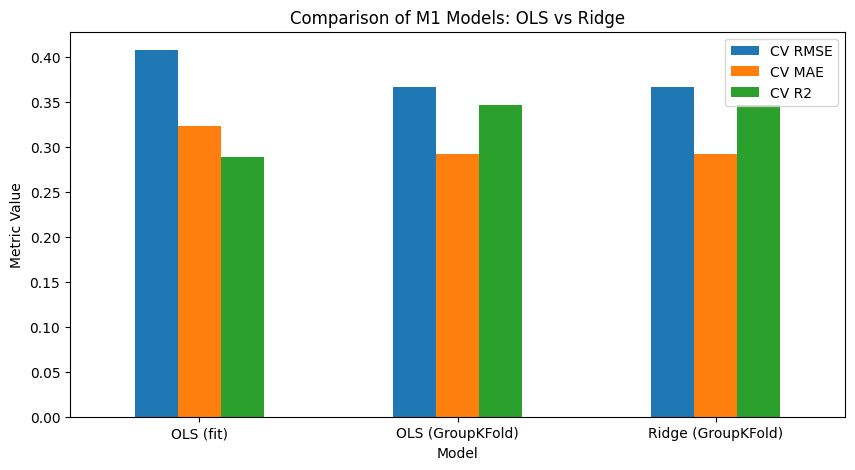

In [16]:
results_df_final = pd.DataFrame([
    {'Model': 'OLS (fit)', 'CV RMSE': rmse_ols_simple, 'CV MAE': mae_ols_simple, 'CV R2': r2_ols_simple, 'Best alpha': None},
    {'Model': 'OLS (GroupKFold)', 'CV RMSE': cv_rmse_ols, 'CV MAE': cv_mae_ols, 'CV R2': cv_r2_ols, 'Best alpha': None},
    {'Model': 'Ridge (GroupKFold)', 'CV RMSE': best_rmse, 'CV MAE': cv_mae_ridge, 'CV R2': cv_r2_ridge, 'Best alpha': best_alpha}
])

results_df_final[['CV RMSE','CV MAE','CV R2']] = results_df_final[['CV RMSE','CV MAE','CV R2']].round(4)
print(results_df_final)

metrics = ['CV RMSE', 'CV MAE', 'CV R2']
results_df_final.set_index('Model')[metrics].plot(kind='bar', figsize=(10,5))
plt.title('Comparison of M1 Models: OLS vs Ridge')
plt.ylabel('Metric Value')
plt.xticks(rotation=0)
plt.show()


# Feature Importance и SHAP для Ridge

C:\PyEnvs\clean_env\lib\site-packages\shap\explainers\_linear.py:99: FutureWarning: The feature_perturbation option is now deprecated in favor of using the appropriate masker (maskers.Independent, maskers.Partition or maskers.Impute).
  warnings.warn(wmsg, FutureWarning)
C:\Users\Angelina\AppData\Local\Temp\ipykernel_37092\4121959599.py:24: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


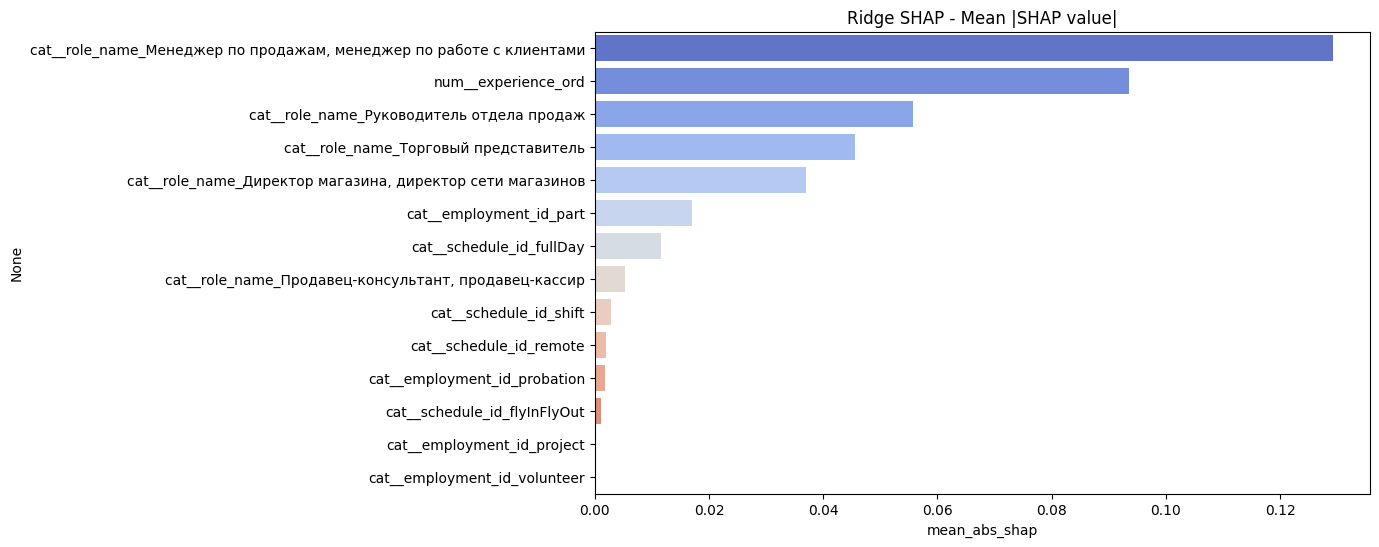

In [33]:
# Предварительно преобразуем X через preprocessor
X_ridge = best_model.named_steps['preprocessor'].transform(df_m1_cv[features])
feature_names = best_model.named_steps['preprocessor'].get_feature_names_out()

# Создаем explainer
explainer = shap.LinearExplainer(
    best_model.named_steps['model'],
    X_ridge,
    feature_perturbation="interventional"
)

# Вычисляем SHAP
shap_values = explainer.shap_values(X_ridge)

# Считаем mean absolute SHAP
shap_df = pd.DataFrame(
    np.abs(shap_values).mean(axis=0),
    index=feature_names,
    columns=['mean_abs_shap']
).sort_values('mean_abs_shap', ascending=False)

# Строим график
plt.figure(figsize=(10,6))
sns.barplot(
    x='mean_abs_shap',
    y=shap_df.index,
    data=shap_df.reset_index(),
    palette='coolwarm'
)
plt.title("Ridge SHAP - Mean |SHAP value|")
plt.show()